# 01 — Converging scheduler: cursor convergence and worker balance

Pure simulation: no GPU, no torch, fully seeded. Uses the **real**
`Scheduler` and the `FakeBackend` length-sensitive cost model
(`latency_s + latency_per_token * len(text)` per item), the same one the
scheduling tests use.

Run from the repo root:

```
uv sync --extra dev
uv run jupyter lab
```

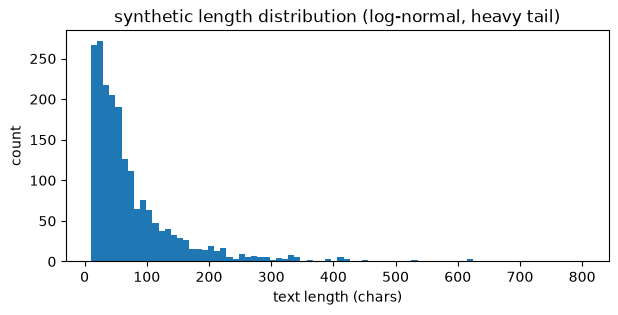

n=2000  median=51  mean=78  p95=228  max=803  total=156205


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from embedx.backend import FakeBackend
from embedx.engine import Scheduler, Side

# Synthetic corpus: log-normal lengths are a reasonable stand-in for
# headline/news corpora — many short texts, a heavy tail of long ones.
# Parameters: underlying normal mean=4.0, sigma=0.9, clipped to [10, 3000],
# n=2000, char lengths as the token proxy (length_fn=len downstream).
rng = np.random.default_rng(7)
N = 2000
lengths = np.clip(rng.lognormal(mean=4.0, sigma=0.9, size=N).astype(int), 10, 3000)
texts = ["x" * int(n) for n in lengths]
items = list(enumerate(texts))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(lengths, bins=80)
ax.set_xlabel("text length (chars)")
ax.set_ylabel("count")
ax.set_title("synthetic length distribution (log-normal, heavy tail)")
plt.show()

print(f"n={N}  median={np.median(lengths):.0f}  mean={lengths.mean():.0f}  "
      f"p95={np.percentile(lengths, 95):.0f}  max={lengths.max()}  total={lengths.sum()}")

With seed 7 this gives: median **51**, mean **78**, p95 **228**, max **803**,
total **156,205** chars across 2,000 texts.

In [3]:
def batch_cost(backend, batch):
    return sum(backend.latency_s + backend.latency_per_token * len(t) for _, t in batch)


def simulate(items, workers):
    # Same event loop as tests/test_scheduling.py: always advance whichever
    # worker has the smallest clock; it claims, its clock grows by the
    # batch's simulated cost. Records (lo, hi) and clocks at every claim.
    # (_lo/_hi are private; a dev notebook peeking at them is fine.)
    scheduler = Scheduler(items)
    n = len(workers)
    clocks, active = [0.0] * n, [True] * n
    events = []
    while any(active):
        w = min((i for i in range(n) if active[i]), key=lambda i: clocks[i])
        side, budget, backend = workers[w]
        batch = scheduler.claim(side, budget)
        if batch is None:
            active[w] = False
            continue
        start = clocks[w]
        clocks[w] += batch_cost(backend, batch)
        events.append({
            "worker": w, "side": side.value, "start": start, "end": clocks[w],
            "items": len(batch), "tokens": sum(len(t) for _, t in batch),
            "max_len": max(len(t) for _, t in batch),
            "lo": scheduler._lo, "hi": scheduler._hi,
        })
    return events, clocks

In [4]:
# Fast worker on the LONG end, a 3x-slower worker on the SHORT end,
# with a bigger token budget for the fast device.
fast = FakeBackend(dim=4, latency_s=1e-4, latency_per_token=1e-5)
slow = FakeBackend(dim=4, latency_s=3e-4, latency_per_token=3e-5)
workers = [(Side.LONG, 4096, fast), (Side.SHORT, 2048, slow)]

events, clocks = simulate(items, workers)

for w, name in [(0, "fast (LONG)"), (1, "slow (SHORT)")]:
    ev = [e for e in events if e["worker"] == w]
    print(f"{name:13s} items={sum(e['items'] for e in ev):5d}  "
          f"tokens={sum(e['tokens'] for e in ev):7d}  batches={len(ev):3d}  "
          f"mean batch max_len={np.mean([e['max_len'] for e in ev]):6.0f}  "
          f"finish={clocks[w]:.3f}s")
print(f"makespan={max(clocks):.3f}s  finish gap={abs(clocks[0] - clocks[1]):.4f}s "
      f"({abs(clocks[0] - clocks[1]) / max(clocks):.1%} of makespan)")

fast (LONG)   items=  914  tokens= 122732  batches= 32  mean batch max_len=   223  finish=1.319s
slow (SHORT)  items= 1086  tokens=  33473  batches= 18  mean batch max_len=    38  finish=1.330s
makespan=1.330s  finish gap=0.0113s (0.8% of makespan)


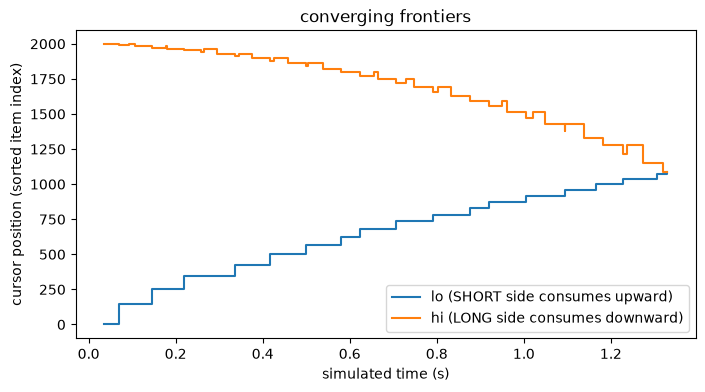

In [5]:
# The two cursors converging over simulated time. SHORT pushes lo up,
# LONG pulls hi down; where they meet, the queue is drained.
fig, ax = plt.subplots(figsize=(8, 4))
for key, label in [("lo", "lo (SHORT side consumes upward)"),
                   ("hi", "hi (LONG side consumes downward)")]:
    pts = sorted((e["end"], e[key]) for e in events)
    ax.step([t for t, _ in pts], [v for _, v in pts], where="post", label=label)
ax.set_xlabel("simulated time (s)")
ax.set_ylabel("cursor position (sorted item index)")
ax.set_title("converging frontiers")
ax.legend()
plt.show()

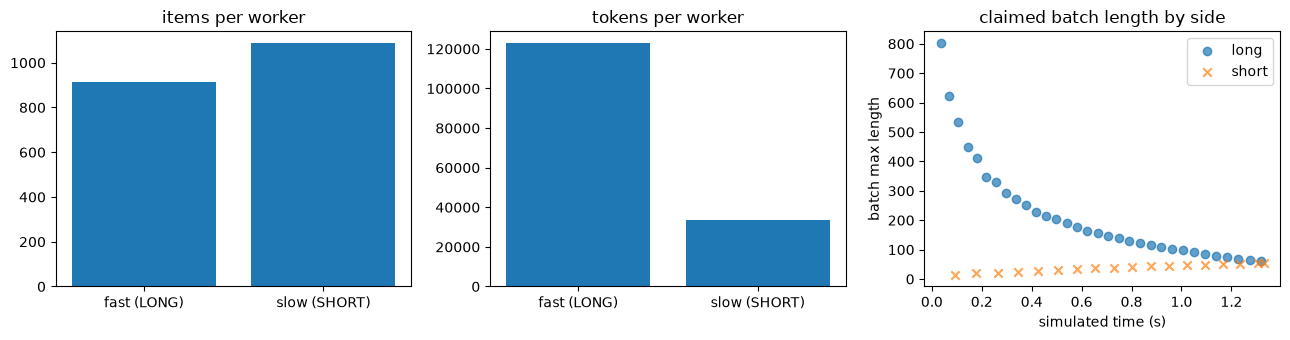

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

names = ["fast (LONG)", "slow (SHORT)"]
item_counts = [sum(e["items"] for e in events if e["worker"] == w) for w in (0, 1)]
token_counts = [sum(e["tokens"] for e in events if e["worker"] == w) for w in (0, 1)]
axes[0].bar(names, item_counts)
axes[0].set_title("items per worker")
axes[1].bar(names, token_counts)
axes[1].set_title("tokens per worker")

for side, marker in [("long", "o"), ("short", "x")]:
    ev = [e for e in events if e["side"] == side]
    axes[2].scatter([e["end"] for e in ev], [e["max_len"] for e in ev],
                    marker=marker, label=side, alpha=0.7)
axes[2].set_xlabel("simulated time (s)")
axes[2].set_ylabel("batch max length")
axes[2].set_title("claimed batch length by side")
axes[2].legend()
plt.tight_layout()
plt.show()

## The numbers (seed 7, 3x speed gap)

- **Work concentrates on the fast worker**: fast (LONG) processes
  **122,732 tokens (78.6%)** in 32 batches vs **33,473 tokens (21.4%)** in 18
  batches for the slow worker.
- **The slow worker's batches are the short ones**: mean claimed batch
  max-length **38** chars on the SHORT side vs **223** on the LONG side.
- **Raw item count is the misleading metric**, so state it plainly: the slow
  worker actually takes *more items* here (1,086 vs 914) because the short
  end packs dozens of tiny texts per claim. Balance is about tokens (= cost),
  not items; the item split crosses 50/50 only around a 4x speed gap (sweep
  below).
- **Both workers finish together**: 1.319s vs 1.330s — a **0.8%** finish gap.
  That closeness, with no up-front partitioning, is the whole design.

 1x  fast item share=0.206  token share=0.538  finish gap=0.0%
 2x  fast item share=0.362  token share=0.711  finish gap=1.9%
 3x  fast item share=0.457  token share=0.786  finish gap=0.8%
 4x  fast item share=0.520  token share=0.828  finish gap=4.2%
 5x  fast item share=0.577  token share=0.861  finish gap=3.0%
 6x  fast item share=0.609  token share=0.879  finish gap=6.9%
 7x  fast item share=0.659  token share=0.904  finish gap=0.9%
 8x  fast item share=0.675  token share=0.911  finish gap=4.3%
 9x  fast item share=0.687  token share=0.916  finish gap=9.8%
10x  fast item share=0.717  token share=0.929  finish gap=5.1%


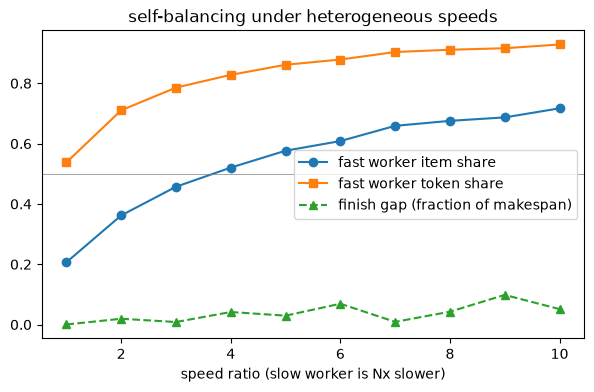

In [7]:
# Sweep worker-speed ratios 1x..10x: does the split self-balance?
ratios = list(range(1, 11))
fast_item_share, fast_token_share, gap_pct = [], [], []
for ratio in ratios:
    slow_r = FakeBackend(dim=4, latency_s=1e-4 * ratio, latency_per_token=1e-5 * ratio)
    ev, cl = simulate(items, [(Side.LONG, 4096, fast), (Side.SHORT, 2048, slow_r)])
    fast_item_share.append(sum(e["items"] for e in ev if e["worker"] == 0) / N)
    fast_token_share.append(
        sum(e["tokens"] for e in ev if e["worker"] == 0) / lengths.sum())
    gap_pct.append(abs(cl[0] - cl[1]) / max(cl))
    print(f"{ratio:2d}x  fast item share={fast_item_share[-1]:.3f}  "
          f"token share={fast_token_share[-1]:.3f}  finish gap={gap_pct[-1]:.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ratios, fast_item_share, "o-", label="fast worker item share")
ax.plot(ratios, fast_token_share, "s-", label="fast worker token share")
ax.plot(ratios, gap_pct, "^--", label="finish gap (fraction of makespan)")
ax.axhline(0.5, color="grey", lw=0.5)
ax.set_xlabel("speed ratio (slow worker is Nx slower)")
ax.set_title("self-balancing under heterogeneous speeds")
ax.legend()
plt.show()

## Sweep result

Fast-worker item share grows monotonically with the speed gap — **0.206 at
1x, 0.457 at 3x, 0.717 at 10x** — with nothing configured per ratio: workers
just come back for more, so the split adapts by construction. The finish gap
stays small throughout (mostly under 5% of makespan, worst ≈10% at 9x, which
is single-batch granularity at the meeting point). This is the
self-balancing claim, demonstrated rather than asserted.